# Release metro map

Interactive network graph showing inter-repository dependencies within a release train. Nodes represent repositories; blue edges show dependency relationships and red edges show parent relationships.

In [1]:
repository_filter: list[str] = []
data_file_dependencies: str = "../samples/release_metro_dependencies_in_use.csv"
data_file_parents: str = "../samples/release_metro_parent_relationships.csv"

In [2]:
import pandas as pd
import plotly.graph_objects as go
import networkx as nx
import code_data_science.palette as palette
from code_data_science import data_table as dt
from moderne_visualizations_misc.reusable.release_metro_utils import (
    build_release_graph,
    compute_release_waves,
)
from moderne_visualizations_misc.reusable.quality_utils import (
    filter_repos,
    short_repo,
    empty_figure,
)
import warnings

warnings.simplefilter("ignore")

_cm = palette.__moderne_color_map
PERIWINKLE = _cm["periwinkle"][500]
MAGENTA = _cm["magenta"][500]
GREEN = _cm["activity_green"][500]

# Load primary table (ProjectCoordinates, overridden by NB_DATA_TABLE)
coords_df = dt.read_csv("../samples/project_coordinates.csv")

# Load additional tables
deps_df = pd.read_csv(data_file_dependencies, on_bad_lines="skip")
parents_df = pd.read_csv(data_file_parents, on_bad_lines="skip")

# Apply repository filter
coords_df = filter_repos(coords_df, repository_filter)
deps_df = filter_repos(deps_df, repository_filter)
parents_df = filter_repos(parents_df, repository_filter)

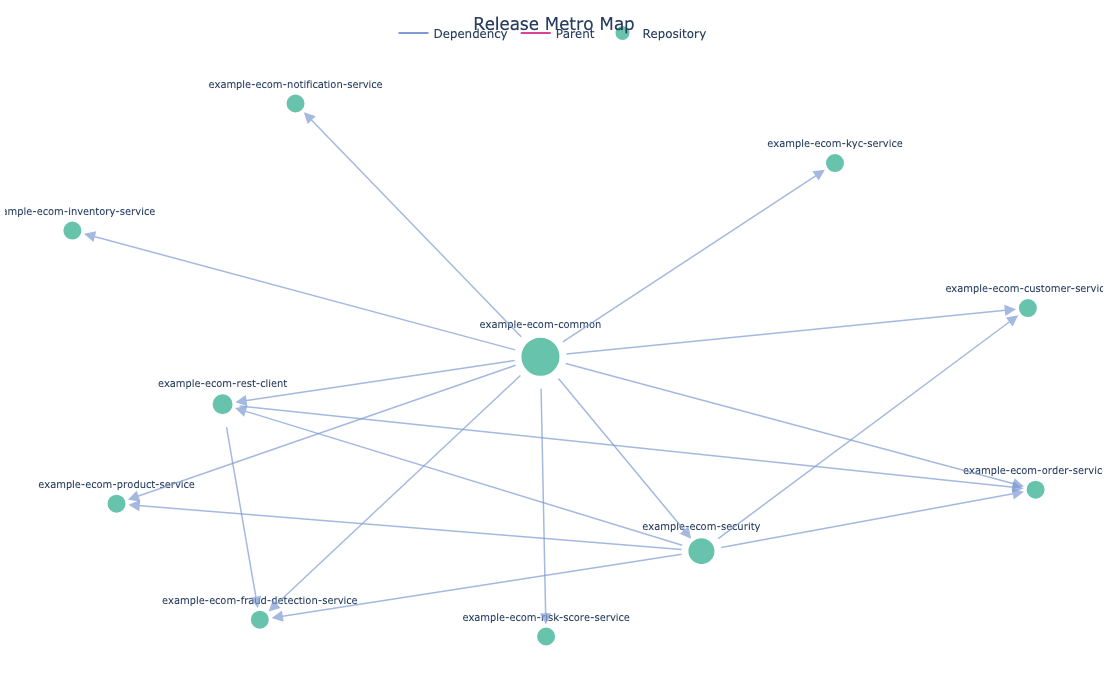

In [3]:
if len(coords_df) == 0:
    fig = empty_figure("No project coordinate data found.")
else:
    G = build_release_graph(coords_df, deps_df, parents_df)

    if len(G.nodes()) == 0:
        fig = empty_figure("No inter-repository dependencies found.")
    else:
        # Compute release waves for coloring
        waves, circular = compute_release_waves(G)
        node_wave: dict[str, int] = {}
        for i, wave in enumerate(waves):
            for node in wave:
                node_wave[node] = i
        for node in circular:
            node_wave[node] = len(waves)

        # Layout
        pos = nx.spring_layout(G, k=2, iterations=50, seed=42)

        # Compute node sizes (needed for standoff calculation)
        node_sizes: dict[str, int] = {}
        for node in G.nodes():
            degree = G.in_degree(node) + G.out_degree(node)
            node_sizes[node] = max(20, 10 + degree * 3)

        # --- Arrow annotations with standoff so tips stay outside nodes ---
        arrow_annotations = []
        for u, v, data in G.edges(data=True):
            x0, y0 = pos[u]
            x1, y1 = pos[v]
            is_parent = data.get("edge_type") == "parent"
            color = MAGENTA if is_parent else PERIWINKLE

            arrow_annotations.append(
                dict(
                    ax=x0,
                    ay=y0,
                    x=x1,
                    y=y1,
                    xref="x",
                    yref="y",
                    axref="x",
                    ayref="y",
                    showarrow=True,
                    arrowhead=2,
                    arrowsize=1.5,
                    arrowwidth=1.5,
                    arrowcolor=color,
                    opacity=0.7,
                    standoff=node_sizes[v] // 2 + 2,
                    startstandoff=node_sizes[u] // 2 + 2,
                )
            )

        # --- Node trace (on top of edges) ---
        node_x = []
        node_y = []
        node_text = []
        node_hover = []
        sizes = []

        for node in G.nodes():
            x, y = pos[node]
            node_x.append(x)
            node_y.append(y)
            node_text.append(short_repo(node))
            sizes.append(node_sizes[node])

            in_deps = list(G.predecessors(node))
            out_deps = list(G.successors(node))
            wave = node_wave.get(node, -1)
            hover = (
                f"<b>{node}</b><br>"
                f"Wave: {wave}<br>"
                f"Depends on: {len(in_deps)} repos<br>"
                f"Required by: {len(out_deps)} repos"
            )
            node_hover.append(hover)

        node_trace = go.Scatter(
            x=node_x,
            y=node_y,
            mode="markers+text",
            text=node_text,
            textposition="top center",
            textfont=dict(size=10),
            hoverinfo="text",
            hovertext=node_hover,
            marker=dict(
                size=sizes,
                color=GREEN,
                line=dict(width=2, color="white"),
            ),
            name="Repository",
            showlegend=True,
        )

        # Legend-only traces for edge types (invisible points)
        dep_legend = go.Scatter(
            x=[None],
            y=[None],
            mode="lines",
            line=dict(width=2, color=PERIWINKLE),
            name="Dependency",
            showlegend=True,
        )
        parent_legend = go.Scatter(
            x=[None],
            y=[None],
            mode="lines",
            line=dict(width=2, color=MAGENTA),
            name="Parent",
            showlegend=True,
        )

        fig = go.Figure(data=[dep_legend, parent_legend, node_trace])

        title = "Release Metro Map"
        if circular:
            title += f" ({len(circular)} circular dependencies)"

        fig.update_layout(
            title=dict(text=title, x=0.5, xanchor="center"),
            hovermode="closest",
            margin=dict(b=20, l=5, r=5, t=60),
            xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
            yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
            plot_bgcolor="white",
            legend=dict(
                orientation="h",
                yanchor="bottom",
                y=1.02,
                xanchor="center",
                x=0.5,
            ),
            height=700,
            annotations=arrow_annotations,
        )

fig.show(renderer="plotly_mimetype")